| Node   | Lat   | Lon   | Approx Area Covered               |
| ------ | ----- | ----- | --------------------------------- |
| **0**  | 33.25 | 74.25 | Muzaffarabad / Hattian Bala (PoK) |
| **1**  | 33.25 | 74.75 | Uri / Chakothi area               |
| **2**  | 33.25 | 75.25 | Shopian / Pulwama region          |
| **3**  | 33.25 | 75.75 | Kulgam / Qazigund area            |
| **4**  | 33.75 | 74.25 | Kupwara / Tangdhar region         |
| **5**  | 33.75 | 74.75 | Baramulla / Uri region            |
| **6**  | 33.75 | 75.25 | **Srinagar / Budgam**             |
| **7**  | 33.75 | 75.75 | Anantnag / Pahalgam               |
| **8**  | 34.25 | 74.25 | Keran / Karnah valley             |
| **9**  | 34.25 | 74.75 | Bandipora / Wular Lake            |
| **10** | 34.25 | 75.25 | Ganderbal / Sonamarg              |
| **11** | 34.25 | 75.75 | Dras / Kargil approach            |
| **12** | 34.75 | 74.25 | Neelum Valley (Athmuqam region)   |
| **13** | 34.75 | 74.75 | Tulail Valley / Gurez             |
| **14** | 34.75 | 75.25 | Zojila Pass region                |
| **15** | 34.75 | 75.75 | Kargil / Ladakh border area       |


In [1]:
import xarray as xr

pre = xr.open_dataset("cru_ts4.07.1901.2022.pre.dat.nc\cru_ts4.07.1901.2022.pre.dat.nc")
tmp = xr.open_dataset("cru_ts4.07.1901.2022.tmp.dat.nc\cru_ts4.07.1901.2022.tmp.dat.nc")
vap = xr.open_dataset("cru_ts4.07.1901.2022.vap.dat.nc\cru_ts4.07.1901.2022.vap.dat.nc")

In [2]:
lat_range = slice(33, 35)
lon_range = slice(74, 76)

tmp_k = tmp.sel(lat=lat_range, lon=lon_range)
pre_k = pre.sel(lat=lat_range, lon=lon_range)
vap_k = vap.sel(lat=lat_range, lon=lon_range)

In [3]:
tmp_k, pre_k, vap_k = xr.align(tmp_k, pre_k, vap_k)

In [4]:
print(tmp_k.dims)
print(pre_k.dims)
print(vap_k.dims)

FrozenMappingWarningOnValuesAccess({'lon': 4, 'lat': 4, 'time': 1464})
FrozenMappingWarningOnValuesAccess({'lon': 4, 'lat': 4, 'time': 1464})
FrozenMappingWarningOnValuesAccess({'lon': 4, 'lat': 4, 'time': 1464})


In [5]:
combined = xr.merge([
    tmp_k['tmp'],
    pre_k['pre'],
    vap_k['vap']
])

print(combined)

<xarray.Dataset> Size: 293kB
Dimensions:  (lon: 4, lat: 4, time: 1464)
Coordinates:
  * lon      (lon) float32 16B 74.25 74.75 75.25 75.75
  * lat      (lat) float32 16B 33.25 33.75 34.25 34.75
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2022-12-16
Data variables:
    tmp      (time, lat, lon) float32 94kB ...
    pre      (time, lat, lon) float32 94kB ...
    vap      (time, lat, lon) float32 94kB ...
Attributes:
    long_name:                   near-surface temperature
    units:                       degrees Celsius
    correlation_decay_distance:  1200.0


In [6]:
print(combined.isnull().sum())

<xarray.Dataset> Size: 12B
Dimensions:  ()
Data variables:
    tmp      int32 4B 0
    pre      int32 4B 0
    vap      int32 4B 0


In [7]:
df = combined.to_dataframe().reset_index()
print(df.head())

     lon    lat       time        tmp         pre        vap
0  74.25  33.25 1901-01-16   7.300000  104.000000   6.700000
1  74.25  33.25 1901-02-15   8.400001   64.900002   7.300000
2  74.25  33.25 1901-03-16  15.100000   65.400002   9.900001
3  74.25  33.25 1901-04-16  19.200001   45.500000  11.900001
4  74.25  33.25 1901-05-16  24.000000  110.900002  12.100000


In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSummary Statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (23424, 6)

Columns: Index(['lon', 'lat', 'time', 'tmp', 'pre', 'vap'], dtype='object')

Summary Statistics:
                lon           lat                           time  \
count  23424.000000  23424.000000                          23424   
mean      75.000000     34.000000  1961-12-30 21:00:59.016393440   
min       74.250000     33.250000            1901-01-16 00:00:00   
25%       74.625000     33.625000            1931-07-08 12:00:00   
50%       75.000000     34.000000            1961-12-31 12:00:00   
75%       75.375000     34.375000            1992-06-23 12:00:00   
max       75.750000     34.750000            2022-12-16 00:00:00   
std        0.559029      0.559029                            NaN   

                tmp           pre           vap  
count  23424.000000  23424.000000  23424.000000  
mean       7.989542     52.147564      7.437650  
min      -16.500000      0.000000      0.000000  
25%        1.300000     20.475000      4.100000  
50%        8.300000  

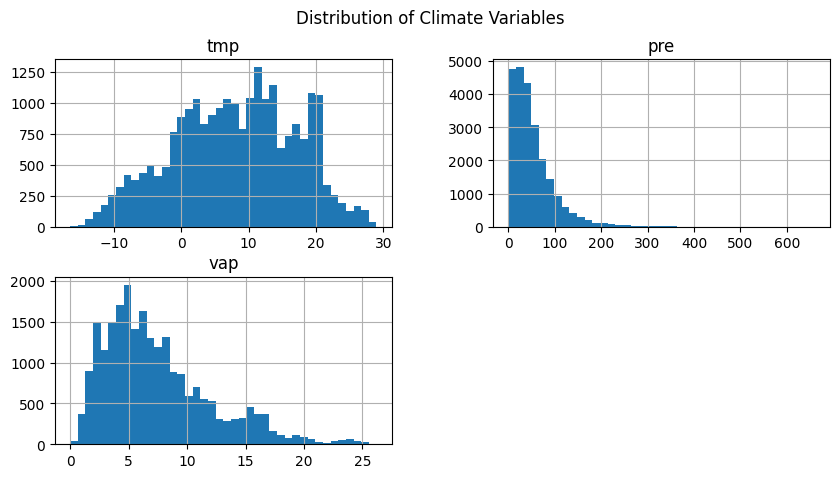

In [9]:
# Shows how temperature, precipitation, and vapor pressure are distributed
import matplotlib.pyplot as plt

df[['tmp','pre','vap']].hist(bins=40, figsize=(10,5))
plt.suptitle("Distribution of Climate Variables")
plt.show()

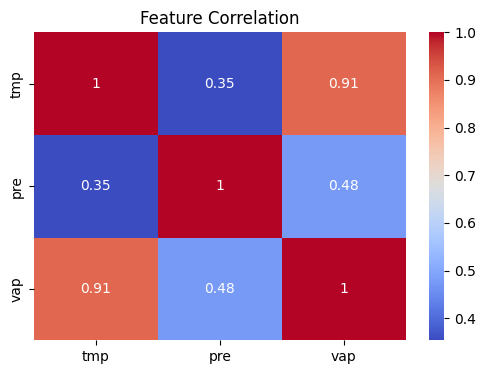

In [11]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[['tmp','pre','vap']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

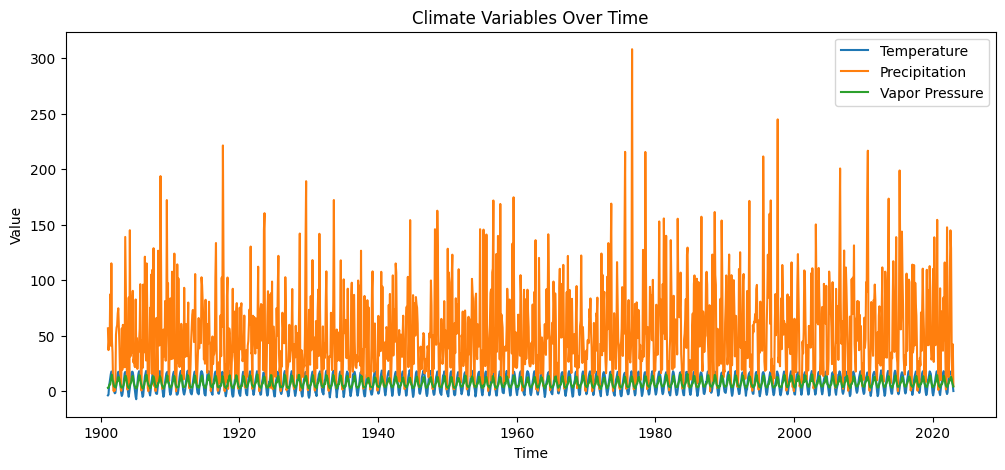

In [12]:
# Shows how climate variables change over time.
df_time = df.groupby("time")[['tmp','pre','vap']].mean()

plt.figure(figsize=(12,5))

plt.plot(df_time.index, df_time['tmp'], label="Temperature")
plt.plot(df_time.index, df_time['pre'], label="Precipitation")
plt.plot(df_time.index, df_time['vap'], label="Vapor Pressure")

plt.legend()
plt.title("Climate Variables Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

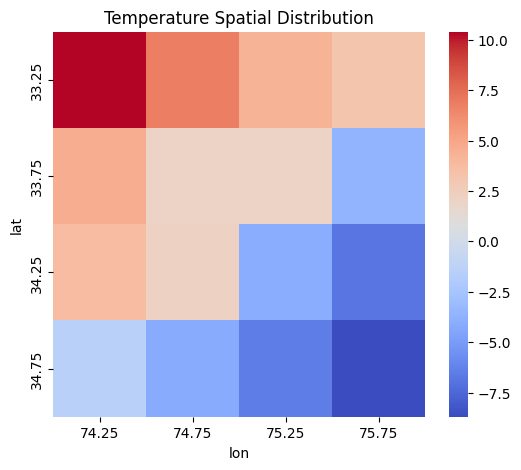

In [13]:
# Shows climate distribution across grid nodes.
latest = df[df['time'] == df['time'].max()]

pivot_tmp = latest.pivot(index='lat', columns='lon', values='tmp')

plt.figure(figsize=(6,5))
sns.heatmap(pivot_tmp, cmap="coolwarm")

plt.title("Temperature Spatial Distribution")
plt.show()

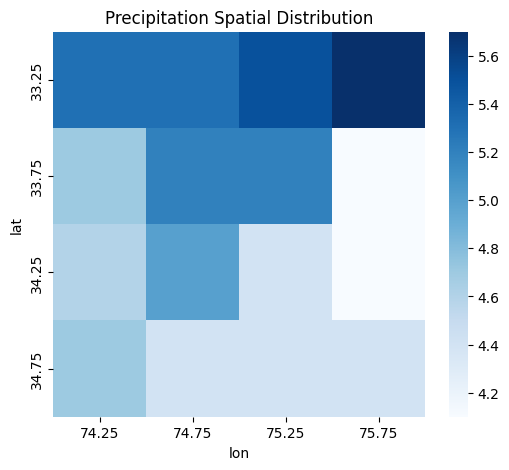

In [14]:
pivot_pre = latest.pivot(index='lat', columns='lon', values='pre')

plt.figure(figsize=(6,5))
sns.heatmap(pivot_pre, cmap="Blues")

plt.title("Precipitation Spatial Distribution")
plt.show()

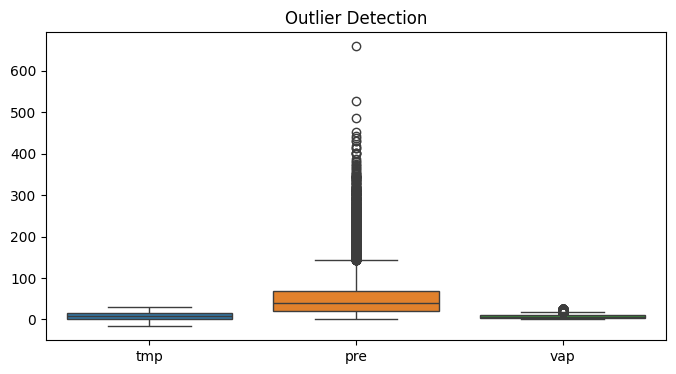

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df[['tmp','pre','vap']])

plt.title("Outlier Detection")
plt.show()

In [13]:
df["node_id"] = df.groupby(["lat","lon"]).ngroup()

In [14]:
df = df.sort_values(["time","node_id"])

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["tmp","pre","vap"]] = scaler.fit_transform(
    df[["tmp","pre","vap"]]
)

In [16]:
import numpy as np
import torch

T = df["time"].nunique()
N = df["node_id"].nunique()
F = 3

data_array = df[["tmp","pre","vap"]].values.reshape(T, N, F)

X = torch.tensor(data_array, dtype=torch.float32)

print(X.shape)

torch.Size([1464, 16, 3])


This means:

T = 1464 months
N = 16 nodes
F = 3 features

Perfect.

In [17]:
# April 1998
snapshot = combined.sel(time="1998-04-16")
snapshot_df = snapshot.to_dataframe().reset_index()
print(snapshot_df)

      lon    lat       time        tmp         pre        vap
0   74.25  33.25 1998-04-16  20.400000  133.400009  12.600000
1   74.25  33.75 1998-04-16  12.700000  122.400002   8.600000
2   74.25  34.25 1998-04-16  12.100000  109.400002   8.400001
3   74.25  34.75 1998-04-16   7.400000  107.500000   6.300000
4   74.75  33.25 1998-04-16  16.100000  131.400009  10.300000
5   74.75  33.75 1998-04-16  10.400001  134.800003   7.700000
6   74.75  34.25 1998-04-16  11.500000  128.400009   8.400001
7   74.75  34.75 1998-04-16   4.700000   99.599998   5.100000
8   75.25  33.25 1998-04-16  13.300000  134.100006   8.600000
9   75.25  33.75 1998-04-16  11.200000  139.000000   8.100000
10  75.25  34.25 1998-04-16   4.400000  105.500000   5.000000
11  75.25  34.75 1998-04-16   2.500000   87.099998   4.300000
12  75.75  33.25 1998-04-16  12.100000  129.600006   7.800000
13  75.75  33.75 1998-04-16   4.400000   97.400002   4.800000
14  75.75  34.25 1998-04-16   1.700000   85.200005   4.100000
15  75.7

* Conceptual Understanding
* At any time t:
* we have full spatial graph:

* Xt=
* Node1:[tmp,pre,vap]
*    Node2:[tmp,pre,vap]
*    Node16:[tmp,pre,vap]

# Input → GNN Layer → ODE Block → Output

* steps:
* We now do:

* 1️⃣ Normalize features
* 2️⃣ Build adjacency matrix
* 3️⃣ Prepare TensorFlow dataset
* 4️⃣ Build simple GNN baseline
* 5️⃣ Then move toward ODE

In [18]:
sequence_length = 24

X_seq = []
Y_seq = []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i+sequence_length])
    Y_seq.append(X[i+sequence_length])

X_seq = torch.stack(X_seq)
Y_seq = torch.stack(Y_seq)

print(X_seq.shape, Y_seq.shape)

torch.Size([1440, 24, 16, 3]) torch.Size([1440, 16, 3])


In [19]:
train_ratio = 0.8
num_samples = X_seq.shape[0]
train_size = int(train_ratio * num_samples)

X_train = X_seq[:train_size]
Y_train = Y_seq[:train_size]

X_test = X_seq[train_size:]
Y_test = Y_seq[train_size:]

In [20]:
coords = df[["lat", "lon", "node_id"]].drop_duplicates().sort_values("node_id")

N = len(coords)
A = np.zeros((N, N))

for i in range(N):
    lat_i, lon_i = coords.iloc[i][["lat", "lon"]]
    for j in range(N):
        lat_j, lon_j = coords.iloc[j][["lat", "lon"]]

        if abs(lat_i - lat_j) == 0.5 and lon_i == lon_j:
            A[i, j] = 1
        if abs(lon_i - lon_j) == 0.5 and lat_i == lat_j:
            A[i, j] = 1

edge_index = torch.tensor(A).nonzero().t().contiguous()

In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GNN_LSTM(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_gcn=32, hidden_lstm=64):
        super(GNN_LSTM, self).__init__()

        self.num_nodes = num_nodes
        self.hidden_gcn = hidden_gcn

        self.conv1 = GCNConv(in_features, hidden_gcn)
        self.conv2 = GCNConv(hidden_gcn, hidden_gcn)
        self.conv3 = GCNConv(hidden_gcn, hidden_gcn)

        self.lstm = nn.LSTM(
            hidden_gcn * num_nodes,
            hidden_lstm,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_lstm, num_nodes * in_features)

    def forward(self, X_seq, edge_index):
        batch_size, seq_len, N, F_in = X_seq.shape
        spatial_outputs = []

        for t in range(seq_len):
            x_t = X_seq[:, t]
            gcn_batch = []

            for b in range(batch_size):
                x = x_t[b]
                x = F.relu(self.conv1(x, edge_index))
                x = F.relu(self.conv2(x, edge_index))
                x = self.conv3(x, edge_index)
                gcn_batch.append(x)

            gcn_batch = torch.stack(gcn_batch)
            gcn_batch = gcn_batch.reshape(batch_size, -1)
            spatial_outputs.append(gcn_batch)

        spatial_outputs = torch.stack(spatial_outputs, dim=1)

        lstm_out, _ = self.lstm(spatial_outputs)

        final_out = self.fc(lstm_out[:, -1])
        final_out = final_out.view(batch_size, N, F_in)

        return final_out

In [39]:
# from torch.utils.data import TensorDataset, DataLoader

# batch_size = 32  

# train_dataset = TensorDataset(X_train, Y_train)
# test_dataset = TensorDataset(X_test, Y_test)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# import torch

# model = GNN_LSTM(num_nodes=N, in_features=3)

# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# loss_fn = torch.nn.SmoothL1Loss()


# epochs = 50

# for epoch in range(epochs):
#     model.train()
#     total_train_loss = 0

#     for xb, yb in train_loader:
#         optimizer.zero_grad()

#         pred = model(xb, edge_index)
#         loss = loss_fn(pred, yb)

#         loss.backward()
#         optimizer.step()

#         total_train_loss += loss.item()

#     avg_train_loss = total_train_loss / len(train_loader)

#     # ---- Evaluate on Test ----
#     model.eval()
#     total_test_loss = 0

#     with torch.no_grad():
#         for xb, yb in test_loader:
#             pred = model(xb, edge_index)
#             loss = loss_fn(pred, yb)
#             total_test_loss += loss.item()

#     avg_test_loss = total_test_loss / len(test_loader)

#     print(f"Epoch {epoch+1}/{epochs} | "
#           f"Train Loss: {avg_train_loss:.4f} | "
#           f"Test Loss: {avg_test_loss:.4f}")

In [ ]:
# save model
import torch
import joblib  # for saving scaler

# ---- Save model weights ----
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "gnn_lstm_model.pth")

# ---- Save scaler separately ----
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [23]:
model = GNN_LSTM(num_nodes=N, in_features=3)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
checkpoint = torch.load("gnn_lstm_model.pth")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [25]:
import joblib

scaler = joblib.load("scaler.pkl")

print("Scaler loaded successfully!")

Scaler loaded successfully!


d:\old\gnode_datasets\.venv2\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [26]:
model.eval()

with torch.no_grad():
    pred_test = model(X_test, edge_index)

test_loss = loss_fn(pred_test, Y_test)
print("Test Loss:", test_loss.item())

Test Loss: 0.08788476139307022


In [27]:
pred_np = pred_test.detach().numpy()
true_np = Y_test.detach().numpy()

pred_original = scaler.inverse_transform(pred_np.reshape(-1,3))
true_original = scaler.inverse_transform(true_np.reshape(-1,3))

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_tmp = np.sqrt(mean_squared_error(true_original[:,0], pred_original[:,0]))
rmse_pre = np.sqrt(mean_squared_error(true_original[:,1], pred_original[:,1]))
rmse_vap = np.sqrt(mean_squared_error(true_original[:,2], pred_original[:,2]))

print("RMSE Temp:", rmse_tmp)
print("RMSE Precip:", rmse_pre)
print("RMSE Vap:", rmse_vap)

RMSE Temp: 1.3373107
RMSE Precip: 35.716545
RMSE Vap: 0.9365701


In [28]:
# predictions
model.eval()

with torch.no_grad():
    pred_test = model(X_test, edge_index)

pred_np = pred_test.detach().cpu().numpy()
true_np = Y_test.detach().cpu().numpy()

# scale to oringia;
import numpy as np

# Flatten for inverse scaling
pred_original = scaler.inverse_transform(
    pred_np.reshape(-1, 3)
)

true_original = scaler.inverse_transform(
    true_np.reshape(-1, 3)
)

# Reshape back
num_samples = pred_np.shape[0]
num_nodes = pred_np.shape[1]

pred_original = pred_original.reshape(num_samples, num_nodes, 3)
true_original = true_original.reshape(num_samples, num_nodes, 3)

time_values = df["time"].unique()

prediction_times = time_values[sequence_length + int(0.8 * (len(time_values) - sequence_length)):]

import pandas as pd

all_rows = []

coords_sorted = coords.sort_values("node_id")

for i in range(num_samples):  # over time
    for node in range(num_nodes):  # over nodes
        
        all_rows.append({
            "time": prediction_times[i],
            "node_id": node,
            "lat": coords_sorted.iloc[node]["lat"],
            "lon": coords_sorted.iloc[node]["lon"],
            
            "tmp_pred": pred_original[i, node, 0],
            "tmp_actual": true_original[i, node, 0],
            
            "pre_pred": pred_original[i, node, 1],
            "pre_actual": true_original[i, node, 1],
            
            "vap_pred": pred_original[i, node, 2],
            "vap_actual": true_original[i, node, 2],
        })

results_df = pd.DataFrame(all_rows)

print(results_df.head(20))

         time  node_id    lat    lon   tmp_pred  tmp_actual   pre_pred  \
0  1999-01-16        0  33.25  74.25   8.152693    7.900000  68.048279   
1  1999-01-16        1  33.25  74.75   3.893314    4.000000  60.986595   
2  1999-01-16        2  33.25  75.25   1.917054    1.400000  57.216953   
3  1999-01-16        3  33.25  75.75   0.068349    0.100000  59.792717   
4  1999-01-16        4  33.75  74.25   2.230534    1.500000  48.854259   
5  1999-01-16        5  33.75  74.75  -1.155705   -1.000000  47.631138   
6  1999-01-16        6  33.75  75.25  -0.402165   -0.500000  49.579353   
7  1999-01-16        7  33.75  75.75  -7.372173   -7.200000  36.627880   
8  1999-01-16        8  34.25  74.25   0.751951    0.900000  41.714230   
9  1999-01-16        9  34.25  74.75  -0.127376   -0.300000  51.294437   
10 1999-01-16       10  34.25  75.25  -7.543753   -7.500000  41.806080   
11 1999-01-16       11  34.25  75.75 -10.449042  -10.400001  33.645355   
12 1999-01-16       12  34.75  74.25  

In [29]:
# first month
results_df[results_df["time"] == prediction_times[0]]

,time,node_id,lat,lon,tmp_pred,tmp_actual,pre_pred,pre_actual,vap_pred,vap_actual
0,1999-01-16,0,33.25,74.25,8.152693,7.900000,68.048279,134.500000,7.612954,7.400000
1,1999-01-16,1,33.25,74.75,3.893314,4.000000,60.986595,122.200005,6.097393,6.100000
2,1999-01-16,2,33.25,75.25,1.917054,1.400000,57.216953,119.500000,4.835139,5.000000
3,1999-01-16,3,33.25,75.75,0.068349,0.100000,59.792717,117.400002,4.226538,4.400000
4,1999-01-16,4,33.75,74.25,2.230534,1.500000,48.854259,91.300003,4.642291,4.800000
5,1999-01-16,5,33.75,74.75,-1.155705,-1.000000,47.631138,99.200005,4.125390,4.100000
6,1999-01-16,6,33.75,75.25,-0.402165,-0.500000,49.579353,107.400002,4.413564,4.400000
7,1999-01-16,7,33.75,75.75,-7.372173,-7.200000,36.627880,71.000000,2.352946,2.400000
8,1999-01-16,8,34.25,74.25,0.751951,0.900000,41.714230,77.700005,4.417521,4.600000
9,1999-01-16,9,34.25,74.75,-0.127376,-0.300000,51.294437,96.099998,4.498070,4.500000


In [30]:
# one specific  node
results_df[results_df["node_id"] == 0]

,time,node_id,lat,lon,tmp_pred,tmp_actual,pre_pred,pre_actual,vap_pred,vap_actual
0,1999-01-16,0,33.25,74.25,8.152693,7.900000,68.048279,134.500000,7.612954,7.400000
16,1999-02-15,0,33.25,74.25,10.001579,10.900001,61.094528,46.700001,7.750162,8.500000
32,1999-03-16,0,33.25,74.25,14.673997,15.000000,81.388077,51.700001,9.832870,10.400001
48,1999-04-16,0,33.25,74.25,20.010262,22.000000,58.985695,63.400002,11.447407,13.800000
64,1999-05-16,0,33.25,74.25,25.012533,25.400000,58.142071,34.100002,14.067897,14.600000
...,...,...,...,...,...,...,...,...,...,...
4528,2022-08-16,0,33.25,74.25,26.256041,24.900000,158.757309,302.500000,22.087864,23.600000
4544,2022-09-16,0,33.25,74.25,23.499863,24.800001,108.547104,85.800003,19.270182,20.800001
4560,2022-10-16,0,33.25,74.25,21.303272,20.500000,43.237865,16.900002,15.250959,14.900001
4576,2022-11-16,0,33.25,74.25,15.558115,14.700000,25.051929,52.000000,10.853962,10.600000


Plot Predicted vs Actual Curves (For One Node)

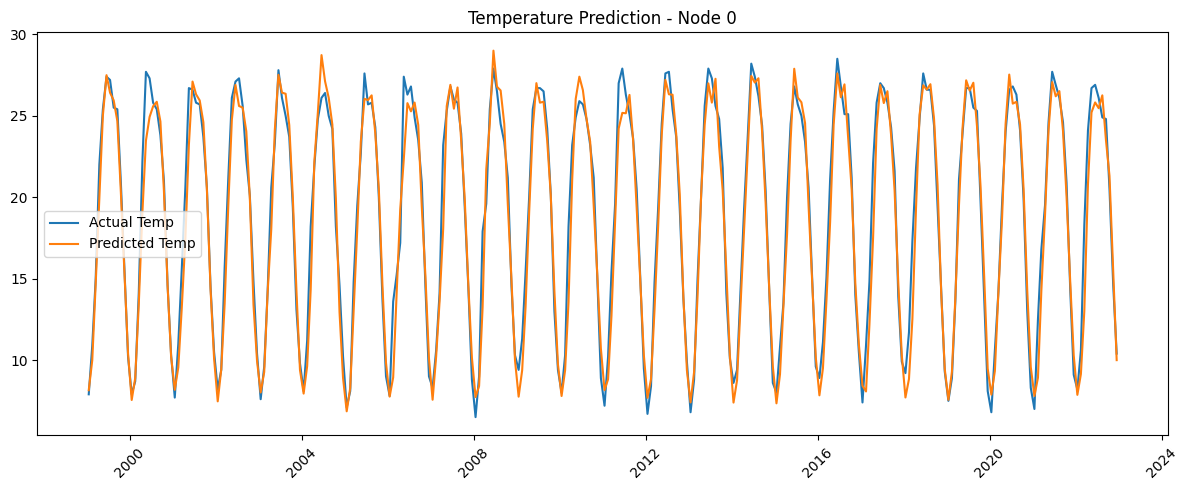

In [31]:
import matplotlib.pyplot as plt

node_id = 0

node_df = results_df[results_df["node_id"] == node_id]

plt.figure(figsize=(12,5))
plt.plot(node_df["time"], node_df["tmp_actual"], label="Actual Temp")
plt.plot(node_df["time"], node_df["tmp_pred"], label="Predicted Temp")
plt.legend()
plt.title(f"Temperature Prediction - Node {node_id}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

precipitation

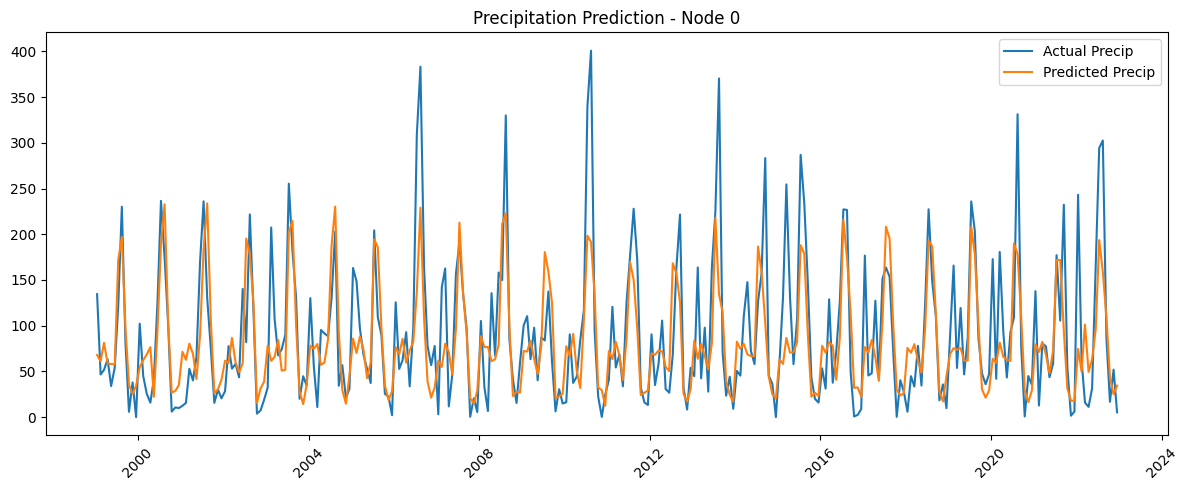

In [32]:
plt.figure(figsize=(12,5))
plt.plot(node_df["time"], node_df["pre_actual"], label="Actual Precip")
plt.plot(node_df["time"], node_df["pre_pred"], label="Predicted Precip")
plt.legend()
plt.title(f"Precipitation Prediction - Node {node_id}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Spatial Prediction Map (For One Month)

In [33]:
sample_time = results_df["time"].unique()[0]

month_df = results_df[results_df["time"] == sample_time]

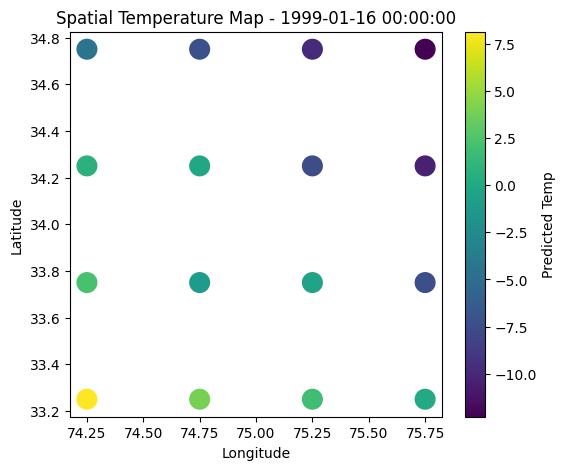

In [34]:
# Plot Spatial Map (Temperature)
plt.figure(figsize=(6,5))

plt.scatter(
    month_df["lon"],
    month_df["lat"],
    c=month_df["tmp_pred"],
    s=200
)

plt.colorbar(label="Predicted Temp")
plt.title(f"Spatial Temperature Map - {sample_time}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

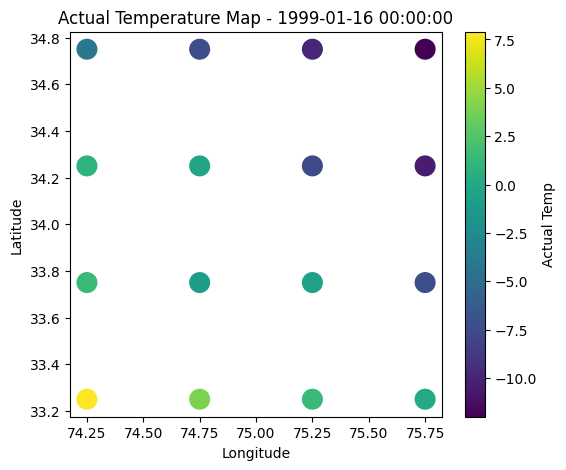

In [35]:
# Compare with Actual Map
plt.figure(figsize=(6,5))

plt.scatter(
    month_df["lon"],
    month_df["lat"],
    c=month_df["tmp_actual"],
    s=200
)

plt.colorbar(label="Actual Temp")
plt.title(f"Actual Temperature Map - {sample_time}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [36]:
# Compute Per-Node RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

node_rmse = []

for node in results_df["node_id"].unique():
    
    node_df = results_df[results_df["node_id"] == node]
    
    rmse_tmp = np.sqrt(mean_squared_error(
        node_df["tmp_actual"],
        node_df["tmp_pred"]
    ))
    
    rmse_pre = np.sqrt(mean_squared_error(
        node_df["pre_actual"],
        node_df["pre_pred"]
    ))
    
    rmse_vap = np.sqrt(mean_squared_error(
        node_df["vap_actual"],
        node_df["vap_pred"]
    ))
    
    node_rmse.append({
        "node_id": node,
        "lat": node_df["lat"].iloc[0],
        "lon": node_df["lon"].iloc[0],
        "RMSE_Temp": rmse_tmp,
        "RMSE_Precip": rmse_pre,
        "RMSE_Vap": rmse_vap
    })

rmse_df = pd.DataFrame(node_rmse)

print(rmse_df)

    node_id    lat    lon  RMSE_Temp  RMSE_Precip  RMSE_Vap
0         0  33.25  74.25   1.459728    53.827736  1.215207
1         1  33.25  74.75   1.526221    50.077251  1.130814
2         2  33.25  75.25   1.432641    49.446728  1.061722
3         3  33.25  75.75   1.254246    46.560371  1.039147
4         4  33.75  74.25   1.452835    34.877205  1.077630
5         5  33.75  74.75   1.252909    36.282597  1.068945
6         6  33.75  75.25   1.404566    38.907112  1.086172
7         7  33.75  75.75   1.241187    29.645239  0.962149
8         8  34.25  74.25   1.434493    28.730753  0.780047
9         9  34.25  74.75   1.421427    31.828398  0.799799
10       10  34.25  75.25   1.165976    27.811377  0.818674
11       11  34.25  75.75   1.262967    24.255011  0.883583
12       12  34.75  74.25   1.327258    25.846859  0.761178
13       13  34.75  74.75   1.231875    24.759857  0.734758
14       14  34.75  75.25   1.209073    23.243979  0.650373
15       15  34.75  75.75   1.249395    

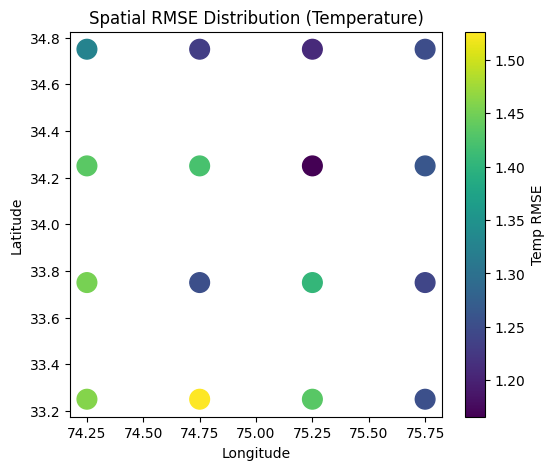

In [37]:
# visulaize rmse spatially
plt.figure(figsize=(6,5))

plt.scatter(
    rmse_df["lon"],
    rmse_df["lat"],
    c=rmse_df["RMSE_Temp"],
    s=200
)

plt.colorbar(label="Temp RMSE")
plt.title("Spatial RMSE Distribution (Temperature)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()